C:\Users\THILAK R\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


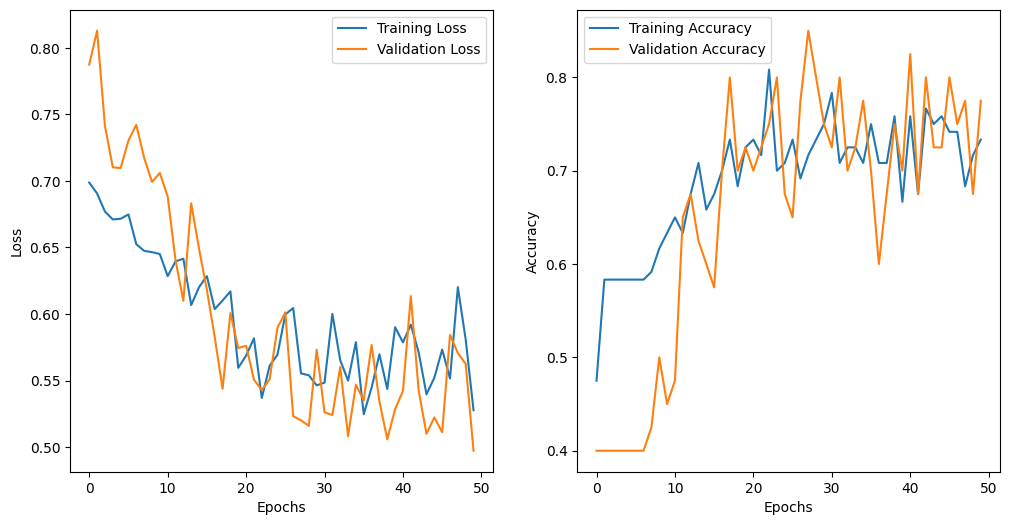

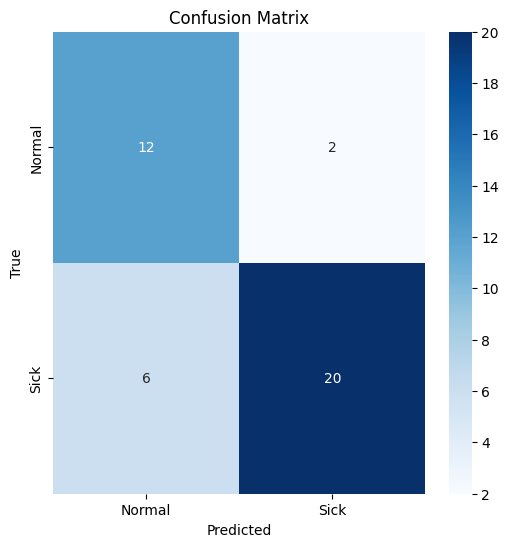

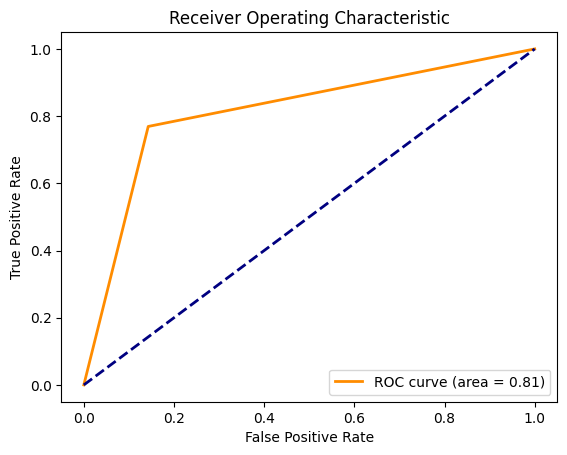

F1 Score: 0.8333
Precision: 0.9091
Recall: 0.7692


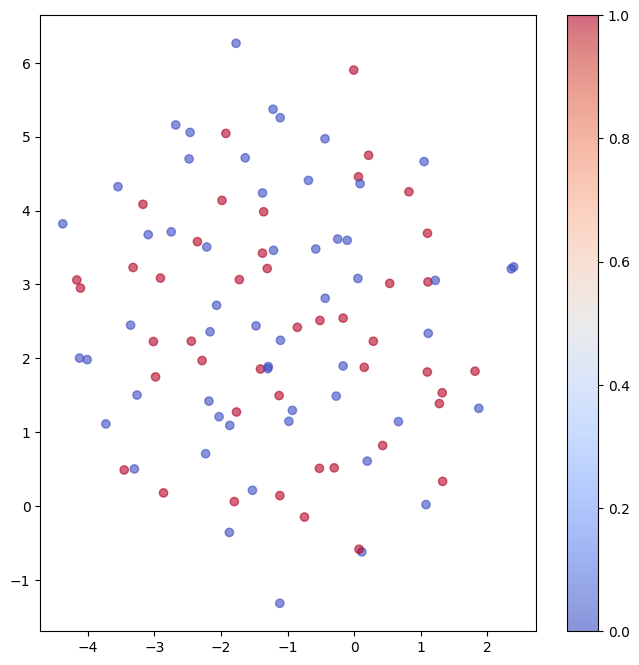

In [56]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Dataset directory
data_dir = r"C:\\Users\\THILAK R\\OneDrive\\Desktop\\BCD_Dataset"

# Define data transformations
transform = transforms.Compose([
    transforms.Resize((160, 120)),  # Match original image size (160x120)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split dataset into train, validation, and test sets
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN Model
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # Define CNN layers
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)  
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)  
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        
        # Calculate flattened size dynamically
        flat_size = self.get_conv_output_size((160, 120))  # Input size 160x120
        
        # Fully connected layers
        self.fc1 = nn.Linear(flat_size, 512)
        self.fc2 = nn.Linear(512, 1)  # Output for binary classification
        self.dropout = nn.Dropout(0.5)  # Dropout to prevent overfitting

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)  # Flattening the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))  # Sigmoid for binary classification
        return x

    def get_conv_output_size(self, input_size):
        x = torch.zeros(1, 3, *input_size)
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        return x.view(x.size(0), -1).size(1)

# Initialize model, loss, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_Model().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Reduced learning rate
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, verbose=True)

# Early stopping
early_stopping_patience = 10
best_val_loss = float('inf')
epochs_since_improvement = 0

# Training loop
num_epochs = 50
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

def train_model():
    global epochs_since_improvement, best_val_loss
    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        
        train_accuracy = correct / total
        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_accuracy)

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels.float())
                val_loss += loss.item()
                preds = (outputs > 0.5).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_accuracy = correct / total
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(val_accuracy)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_since_improvement = 0
        else:
            epochs_since_improvement += 1
        if epochs_since_improvement > early_stopping_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
        
        scheduler.step(val_loss)
    return train_losses, val_losses, train_accuracies, val_accuracies

# Start training
train_losses, val_losses, train_accuracies, val_accuracies = train_model()

# Plot metrics
def plot_metrics():
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Training Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_metrics()

# ROC Curve, Confusion Matrix, Precision, Recall, F1 Score
def evaluate():
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            preds = (outputs > 0.5).float()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Sick'], yticklabels=['Normal', 'Sick'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    print(f'F1 Score: {f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')

evaluate()

# t-SNE Visualization

def tsne_visualization(embeddings, labels):
    # Ensure embeddings are properly reshaped into 2D (n_samples, n_features)
    embeddings = np.array(embeddings)  # Convert to numpy array if not already
    if embeddings.ndim == 1:
        embeddings = embeddings.reshape(-1, 1)  # Reshape if it's a single feature vector
    
    if embeddings.shape[0] > 1:  # Ensure there are enough samples
        tsne = TSNE(n_components=2, random_state=42)
        tsne_result = tsne.fit_transform(embeddings)

        plt.figure(figsize=(8, 8))
        plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='coolwarm', alpha=0.6)
        plt.colorbar()
        plt.show()
    else:
        print("Not enough samples for t-SNE visualization.")

# Example of how to call the function with embeddings and labels:
# Assuming 'embeddings' is your feature vectors and 'labels' is your class labels.
embeddings = np.random.rand(100, 512)  # Example embedding data (100 samples, 512 features)
labels = np.random.randint(0, 2, size=100)  # Example labels (binary: 0 or 1)

# Call tsne_visualization
tsne_visualization(embeddings, labels)


In [69]:
# Save the model
torch.save(model.state_dict(), 'breast_cancer_detection_model.pth')
print("Model saved successfully!")


Model saved successfully!


In [73]:
# Assuming class_weights are defined somewhere, e.g., computed during training or manually set:
# Example class weights (you can calculate these based on the class distribution in your dataset)
class_weights = torch.tensor([1.0, 1.0]).to(device)  # Adjust according to your dataset

# Load the saved model
model = CNN_Model(class_weights=class_weights).to(device)  # Pass class_weights when initializing
model.load_state_dict(torch.load('breast_cancer_detection_model.pth'))
model.eval()  # Set the model to evaluation mode


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_10112\2863556770.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('breast_cancer_detection

CNN_Model(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=19200, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

In [75]:
from PIL import Image

def test_model_with_image(image_path):
    # Define the transformation (same as used for training)
    transform = transforms.Compose([
        transforms.Resize((160, 120)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # Load the image
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension and move to device

    # Make the prediction
    with torch.no_grad():
        output = model(image).squeeze()  # Remove batch dimension
        prediction = (output > 0.5).float()  # Sigmoid output, threshold at 0.5
        label = 'Normal' if prediction.item() == 0 else 'Sick'
        print(f'Prediction: {label}')

# Test with an image (provide the correct path to the image)
test_image_path = r"C:\Users\THILAK R\OneDrive\Desktop\BCD_Dataset\normal\T0001.1.1.S.2012-10-08.00.jpg"  # Replace with the actual image path
test_model_with_image(test_image_path)


Prediction: Normal


C:\Users\THILAK R\AppData\Local\Temp\ipykernel_10112\2633332963.py:92: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("breast_cancer_detectio

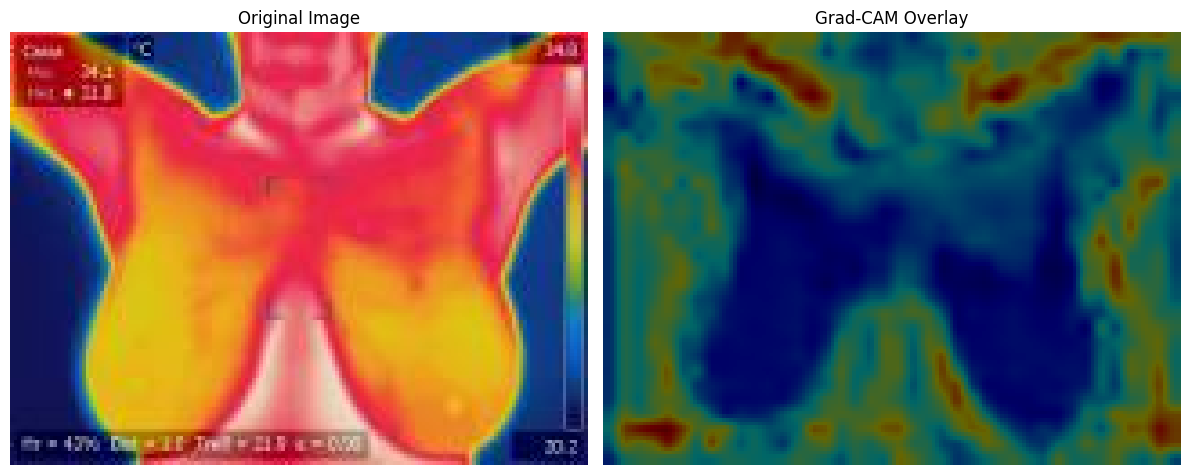

In [95]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Dataset directory
data_dir = r"C:\\Users\\THILAK R\\OneDrive\\Desktop\\BCD_Dataset"

# Define data transformations (ensure same size is used during training and inference)
transform = transforms.Compose([
    transforms.Resize((160, 120)),  # Match original image size (160x120)
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split dataset into train, validation, and test sets
train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# CNN Model
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # Define CNN layers with Batch Normalization
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)  
        self.bn1 = nn.BatchNorm2d(16)  # Batch Normalization after the first convolution
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)  
        self.bn2 = nn.BatchNorm2d(32)  # Batch Normalization after the second convolution
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  
        self.bn3 = nn.BatchNorm2d(64)  # Batch Normalization after the third convolution
        
        # Calculate flattened size dynamically
        flat_size = self.get_conv_output_size((160, 120))  # Input size 160x120
        
        # Fully connected layers
        self.fc1 = nn.Linear(flat_size, 512)
        self.fc2 = nn.Linear(512, 1)  # Output for binary classification
        self.dropout = nn.Dropout(0.5)  # Dropout to prevent overfitting

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))  # Apply batch normalization after conv1
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))  # Apply batch normalization after conv2
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn3(self.conv3(x)))  # Apply batch normalization after conv3
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)  # Flattening the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))  # Sigmoid for binary classification
        return x

    def get_conv_output_size(self, input_size):
        x = torch.zeros(1, 3, *input_size)
        x = F.relu(self.bn1(self.conv1(x)))  # Apply batch normalization during flattening
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x)))  # Apply batch normalization during flattening
        x = F.max_pool2d(x, 2)
        x = F.relu(self.bn3(self.conv3(x)))  # Apply batch normalization during flattening
        x = F.max_pool2d(x, 2)
        return x.view(x.size(0), -1).size(1)


# Initialize model, loss, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_Model().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Reduced learning rate

# Load pre-trained model weights (or continue training)
model.load_state_dict(torch.load("breast_cancer_detection_model.pth"))

# Grad-CAM
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = []
        self.activations = []

        # Hook the activations and gradients
        self.hook_layers()

    def hook_layers(self):
        def save_activation(module, input, output):
            self.activations.append(output)

        def save_gradient(module, input, output):
            self.gradients.append(output[0])

        # Register hooks for the target layer
        target_layer = dict(self.model.named_modules())[self.target_layer]
        target_layer.register_forward_hook(save_activation)
        target_layer.register_backward_hook(save_gradient)

    def generate_heatmap(self, image, model_input):
        # Forward pass
        output = self.model(model_input)

        # Compute loss and backward pass
        self.model.zero_grad()  # Reset gradients
        output_idx = torch.argmax(output, dim=1)  # Get class index (max output)
        output[0, output_idx].backward()  # Backpropagate the gradient w.r.t the class

        # Get gradients and activations
        gradient, activation = self.get_gradients(model_input)

        # Compute weights of activations (global average pooling)
        weights = torch.mean(gradient, dim=(2, 3), keepdim=True)

        # Weighted sum of activations
        weighted_activation = weights * activation
        heatmap = torch.sum(weighted_activation, dim=1, keepdim=True).squeeze()

        # Normalize heatmap to the range [0, 1]
        heatmap = heatmap - torch.min(heatmap)
        heatmap = heatmap / torch.max(heatmap)

        return heatmap

    def get_gradients(self, model_input):
        # Ensure that the gradients are computed during the forward pass
        return self.gradients[-1], self.activations[-1]

    def overlay_heatmap(self, image, heatmap):
        # Convert heatmap from tensor to NumPy array on CPU
        heatmap = heatmap.cpu().detach().numpy()
    
        # Resize heatmap to match image size
        heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
        heatmap_resized = np.uint8(255 * heatmap_resized)  # Convert to 8-bit image
        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)  # Apply color map
    
        # Convert image to uint8 if it's not already
        image = np.uint8(image)  # Ensure image is uint8 format
        
        # Overlay the heatmap on the original image
        overlay = cv2.addWeighted(image, 0.6, heatmap_colored, 0.4, 0)
        return overlay


# Test Image Path
test_image_path = r"C:\Users\THILAK R\OneDrive\Desktop\BCD_Dataset\normal\T0001.1.1.S.2012-10-08.00.jpg"

# Load the test image
def load_and_transform_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (160, 120))  # Resize to match model input
    image = np.transpose(image, (2, 0, 1))  # Change to CHW format
    image = torch.tensor(image).float() / 255  # Normalize to [0, 1]
    image = image.unsqueeze(0).to(device)
    return image

image = load_and_transform_image(test_image_path)

# Grad-CAM
grad_cam = GradCAM(model, target_layer='conv3')
model_input = image
output = model(model_input).squeeze()

# Get Grad-CAM heatmap
heatmap = grad_cam.generate_heatmap(image.squeeze().cpu().numpy(), model_input)

# Overlay heatmap on the original image
image_numpy = image.squeeze().cpu().numpy().transpose(1, 2, 0)  # Convert back to HWC
overlay = grad_cam.overlay_heatmap(image_numpy, heatmap)

# Show the original image and the overlay side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 12))

# Plot original image
ax[0].imshow(image_numpy)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Plot heatmap overlay
ax[1].imshow(overlay)
ax[1].set_title("Grad-CAM Overlay")
ax[1].axis('off')

plt.tight_layout()
plt.show()
